In [1]:
# Written by David Schneidinger. Please modify as needed. Email me dschneidinger@g.ucla.edu if you have any questions
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../../src')
import osh5vis
import osh5io
import numpy as np
import os
import scipy
import matplotlib.pyplot as plt
import astropy
import moments
import analysis_utils

In [2]:
sim_dir = "/pscratch/sd/d/dschnei/perlmutter_1.1.1d"
times = [0, 40, 80, 120]
# al_phase_space = [osh5io.read_h5(f"{sim_dir}/MS/PHA/p1x1/al/p1x1-al-{i:06d}.h5") for i in range(len(os.listdir(f"{sim_dir}/MS/PHA/p1x1/al")))]
# e_phase_space = [osh5io.read_h5(f"{sim_dir}/MS/PHA/p1x1/e/p1x1-e-{i:06d}.h5") for i in range(len(os.listdir(f"{sim_dir}/MS/PHA/p1x1/e")))]
al_phase_space = [osh5io.read_h5(f"{sim_dir}/MS/PHA/p1x1/al/p1x1-al-{t:06d}.h5") for t in times]
e_phase_space = [osh5io.read_h5(f"{sim_dir}/MS/PHA/p1x1/e/p1x1-e-{t:06d}.h5") for t in times]


In [3]:
Z = 6
m_i = 26.981 * astropy.constants.m_p
B0 = 100_000 * astropy.units.Gauss
n0 = 5e18 * astropy.units.cm**-3
T_e = 40 * astropy.units.eV
sim = analysis_utils.MagShockZRun(f"{sim_dir}/magshockz_gpu.1d",
                                norm_density = 5e18 * astropy.units.cm**-3, B0 = 100_000 * astropy.units.Gauss, Z = 6,
                                m_i = 27)

In [4]:
T_al = np.array([(moments.moment(al_phase_space[i], axis = "p1", order = 2)
        * astropy.constants.m_e * astropy.constants.c**2 * sim.rqm).to(astropy.units.eV) for i in range(len(al_phase_space))])
T_e = np.array([(moments.moment(e_phase_space[i], axis = "p1", order = 2)
       * astropy.constants.m_e * astropy.constants.c**2).to(astropy.units.eV) for i in range(len(e_phase_space))])

/global/homes/d/dschnei/.conda/envs/analysis/lib/python3.13/site-packages/astropy/units/quantity.py:648: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Text(0.5, 1.0, 'T_e / T_al')

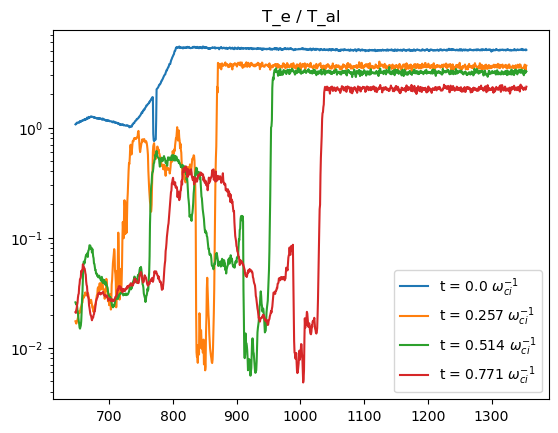

In [18]:
T_e_over_T_al = T_e / T_al
bounds = [1000,-2000] #TODO
x_axis = np.linspace(0, 2648, len(T_e_over_T_al[0])) #TODO make this not shit
for i in range(len(T_e_over_T_al)):
    plt.semilogy(x_axis[bounds[0]:bounds[1]], T_e_over_T_al[i][bounds[0]:bounds[1]], label = f"t = {np.round(al_phase_space[i].run_attrs['TIME'][0] * sim.omega_ci(),3)}"+r" $\omega_{ci}^{-1}$")
    # plt.ylim(0,300)

plt.legend()
plt.title("T_e / T_al")


In [8]:
plt.semilogy(x_axis[bounds[0]:bounds[1]], T_al[-1][bounds[0]:bounds[1]])
# plt.ylim(0,7000)
# plt.xlim(1000,1400)

NameError: name 'x_axis' is not defined

In [19]:
plt.semilogy(x_axis[bounds[0]:bounds[1]], T_e[-1][bounds[0]:bounds[1]])
plt.ylim(0,7000)
# plt.xlim(1000,1400)

TypeError: 'Quantity' object with a scalar value does not support indexing

(<matplotlib.image.AxesImage at 0x7f305f3842d0>,
 <matplotlib.colorbar.Colorbar at 0x7f305f387610>)

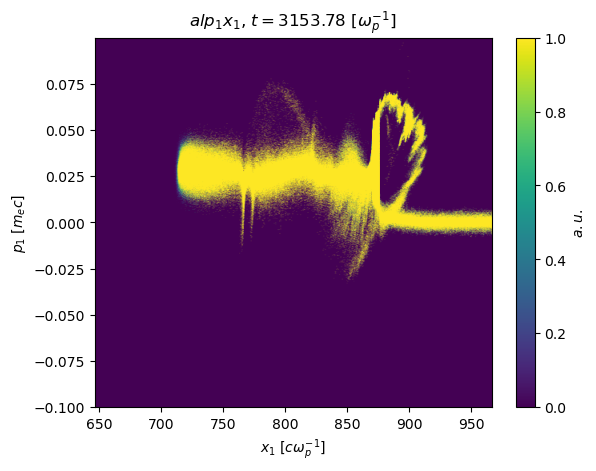

In [14]:
osh5vis.osplot(al_phase_space[-1][:,bounds[0]:bounds[1]], vmax = 1)

(<matplotlib.image.AxesImage at 0x7f305f369310>,
 <matplotlib.colorbar.Colorbar at 0x7f305f16c690>)

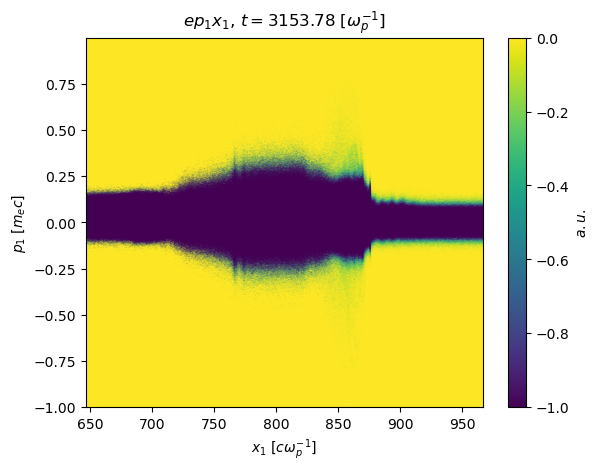

In [15]:
osh5vis.osplot(e_phase_space[-1][:,bounds[0]:bounds[1]], vmin = -1)